# Laboratorio 4. Análisis de Datos Geoespaciales

**Ihan Marroquín - 23108**  
**Diego Patzán - 23525**

Este cuaderno estudia la señal estimada de cianobacteria en los lagos Atitlán y
Amatitlán. La idea no es reemplazar una muestra de agua, sino observar dónde y
cuándo conviene prestar más atención. Se trabajó únicamente con las 22 fechas
indicadas en la guía y con las bandas necesarias de Sentinel-2 L2A.

## Preparación

El análisis usa una resolución de 120 metros. Con ella se conservan la forma y
los contrastes principales de ambos lagos, pero la descarga se mantiene ligera.
Para repetir la consulta basta cambiar `ACTUALIZAR_DATOS` a `True`.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

carpeta_actual = Path.cwd().resolve()
RAIZ = carpeta_actual.parent if carpeta_actual.name == "notebooks" else carpeta_actual
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.analisis_completo import CARPETA_FIGURAS, ejecutar_pipeline

ACTUALIZAR_DATOS = False
resultados = ejecutar_pipeline(forzar_descarga=ACTUALIZAR_DATOS)
metricas = resultados["metricas"].copy()
correlaciones = resultados["correlaciones"].copy()
resumen = resultados["resumen"].copy()
estacionalidad = resultados["estacionalidad"].copy()

print(f"Proyecto: {RAIZ}")
print(f"Observaciones procesadas: {len(metricas)}")

Proyecto: C:\Users\VICTUS\Desktop\8vo Semestre\Data\Lab4\lab4
Observaciones procesadas: 22


## 1. Conexión con la API de Sentinel-2

El avance conserva la conexión de openEO con Copernicus. Para completar el
laboratorio se consultó además el catálogo STAC de Planetary Computer, que
publica escenas Sentinel-2 L2A y permite leer solamente la ventana de los lagos.
No se guardan contraseñas ni se descargan escenas completas.

In [2]:
pd.Series({
    "openEO": "https://openeo.dataspace.copernicus.eu",
    "STAC": "https://planetarycomputer.microsoft.com/api/stac/v1",
    "colección": "sentinel-2-l2a",
}, name="Configuración")

openEO                  https://openeo.dataspace.copernicus.eu
STAC         https://planetarycomputer.microsoft.com/api/st...
colección                                       sentinel-2-l2a
Name: Configuración, dtype: object

## 2. Obtención de los datos necesarios

Por fecha se leen B02, B03, B04, B08 y la capa de calidad SCL. Se retiran nubes,
sombras, nieve y valores inválidos. La tabla deja trazabilidad de la escena y de
los píxeles de agua que realmente entraron al cálculo.

In [3]:
display(metricas[[
    "lago", "fecha", "escena", "nubosidad_escena_pct",
    "pixeles_agua_validos",
]].round(2))

,lago,fecha,escena,nubosidad_escena_pct,pixeles_agua_validos
0,Amatitlan,2025-01-28,S2B_MSIL2A_20250128T162439_R040_T15PYS_2025012...,13.53,821
1,Amatitlan,2025-04-15,S2A_MSIL2A_20250415T162701_R040_T15PYS_2025041...,5.50,884
2,Amatitlan,2025-04-28,S2B_MSIL2A_20250428T161829_R040_T15PYS_2025042...,12.33,850
3,Amatitlan,2025-11-24,S2B_MSIL2A_20251124T162519_R040_T15PYS_2025112...,15.08,810
4,Amatitlan,2026-01-08,S2C_MSIL2A_20260108T162651_R040_T15PYS_2026010...,1.20,757
5,Amatitlan,2026-02-02,S2B_MSIL2A_20260202T162409_R040_T15PYS_2026020...,0.39,757
6,Amatitlan,2026-02-07,S2C_MSIL2A_20260207T162441_R040_T15PYS_2026020...,23.73,825
7,Amatitlan,2026-03-29,S2C_MSIL2A_20260329T161851_R040_T15PYS_2026032...,6.58,884
8,Amatitlan,2026-04-13,S2B_MSIL2A_20260413T161829_R040_T15PYS_2026041...,10.61,916
9,Amatitlan,2026-04-28,S2C_MSIL2A_20260428T161901_R040_T15PYS_2026042...,4.96,723


## 3. Cálculo de NDVI, NDWI y cianobacteria

- **NDVI** ayuda a reconocer vegetación y bordes.
- **NDWI** resalta el agua y sirve como máscara del lago.
- **Cya** usa la ecuación de Se2WaQ:

`Cya = 115530.31 × ((B03 × B04) / B02) ^ 2.38`

La escala se limita a 0-100, como la visualización original. Un valor alto es
una señal de vigilancia, no una confirmación de toxicidad.

In [4]:
display(metricas[[
    "lago", "fecha", "ndvi_promedio", "ndwi_promedio",
    "cianobacteria_promedio", "cianobacteria_mediana",
]].round(3))

,lago,fecha,ndvi_promedio,ndwi_promedio,cianobacteria_promedio,cianobacteria_mediana
0,Amatitlan,2025-01-28,-0.357,0.575,8.717,6.794
1,Amatitlan,2025-04-15,-0.078,0.262,95.076,100.000
2,Amatitlan,2025-04-28,-0.047,0.264,95.328,100.000
3,Amatitlan,2025-11-24,-0.367,0.518,10.483,7.014
4,Amatitlan,2026-01-08,-0.111,0.386,18.155,14.969
5,Amatitlan,2026-02-02,-0.053,0.167,14.913,12.261
6,Amatitlan,2026-02-07,-0.189,0.382,8.764,7.719
7,Amatitlan,2026-03-29,-0.064,0.300,96.243,100.000
8,Amatitlan,2026-04-13,-0.015,0.263,98.896,100.000
9,Amatitlan,2026-04-28,0.005,0.278,98.207,100.000


## 4. Análisis temporal

La primera línea muestra el promedio por fecha. La segunda indica qué porcentaje
del agua válida supera Cya 20. Ver ambas evita confundir un foco pequeño e
intenso con una señal extendida por casi todo el lago.

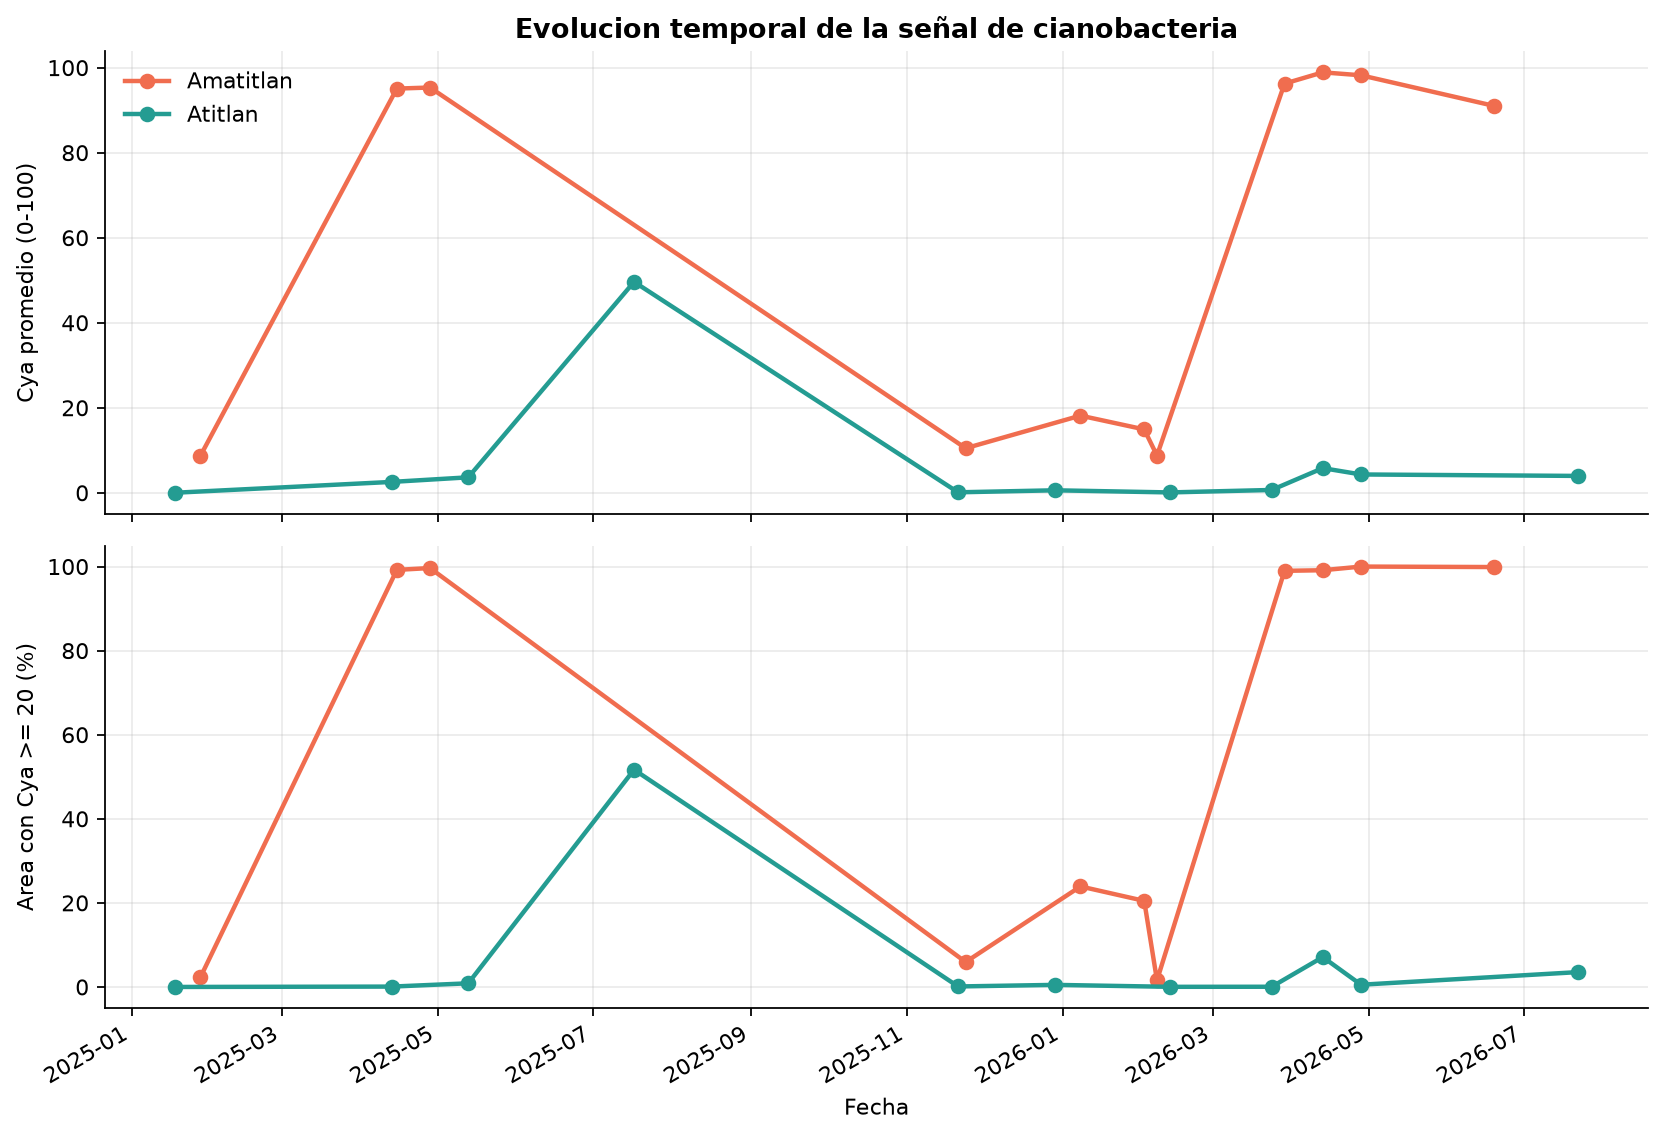

,lago,fecha,cianobacteria_promedio,area_cya_alta_pct
8,Amatitlan,2026-04-13,98.90,99.13
14,Atitlan,2025-07-17,49.62,51.68


In [5]:
display(Image(filename=str(CARPETA_FIGURAS / "evolucion_temporal.png"), width=900))
picos = metricas.loc[
    metricas.groupby("lago")["cianobacteria_promedio"].idxmax(),
    ["lago", "fecha", "cianobacteria_promedio", "area_cya_alta_pct"],
]
display(picos.round(2))

Amatitlán alterna periodos bajos con episodios muy extendidos y cercanos al
límite superior de la escala. Su máximo promedio aparece el 13 de abril de 2026
y la mayor extensión el 28 de abril de 2026. Atitlán permanece bajo en la mayor
parte del periodo, pero el 17 de julio de 2025 presenta un aumento marcado. Esa
fecha tiene menos píxeles válidos y debe interpretarse con más cautela.

## 5. Análisis espacial

Los mosaicos comparan todas las fechas usando la misma escala. Los mapas de
persistencia resumen el porcentaje de observaciones en que cada zona superó el
umbral Cya 20.

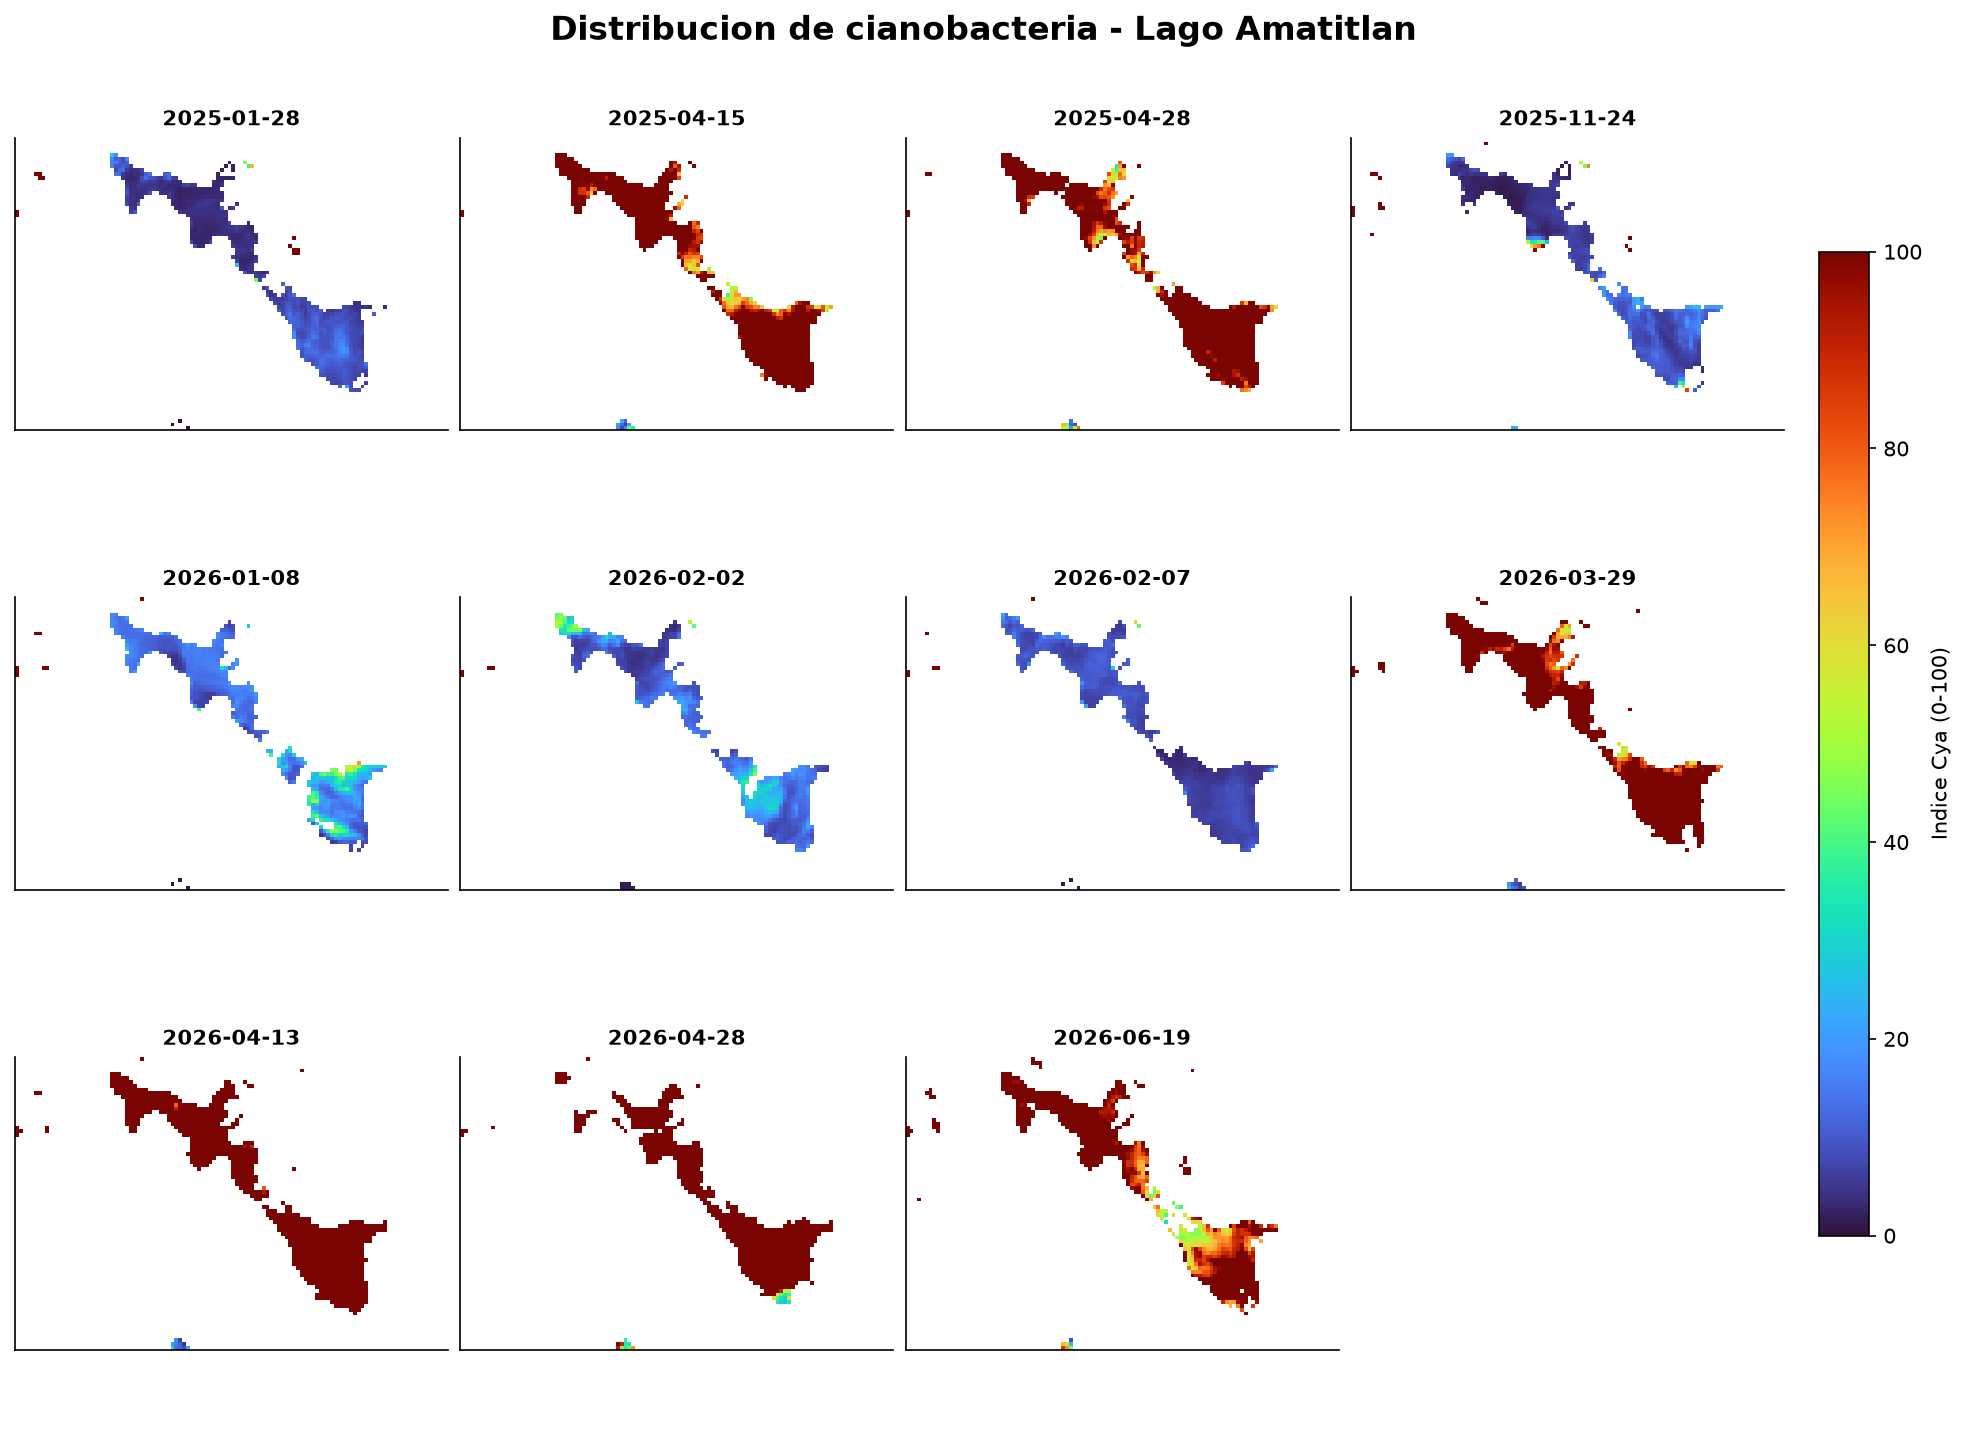

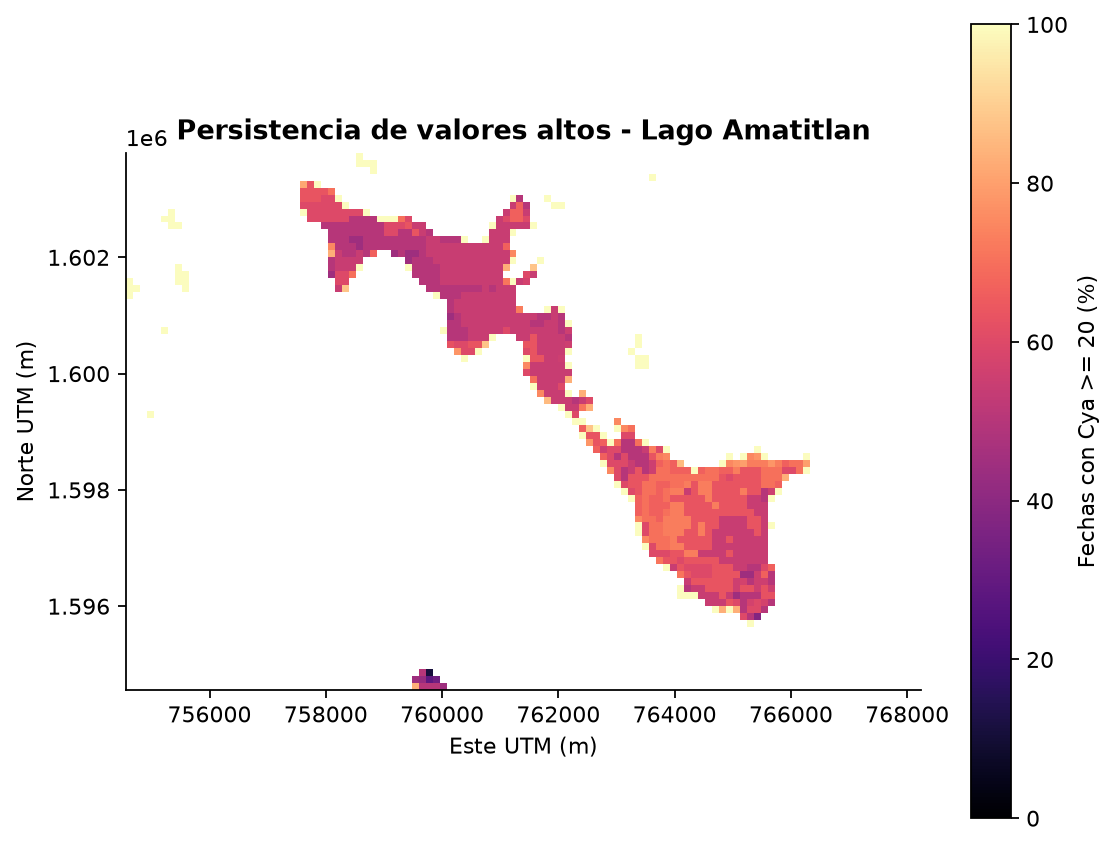

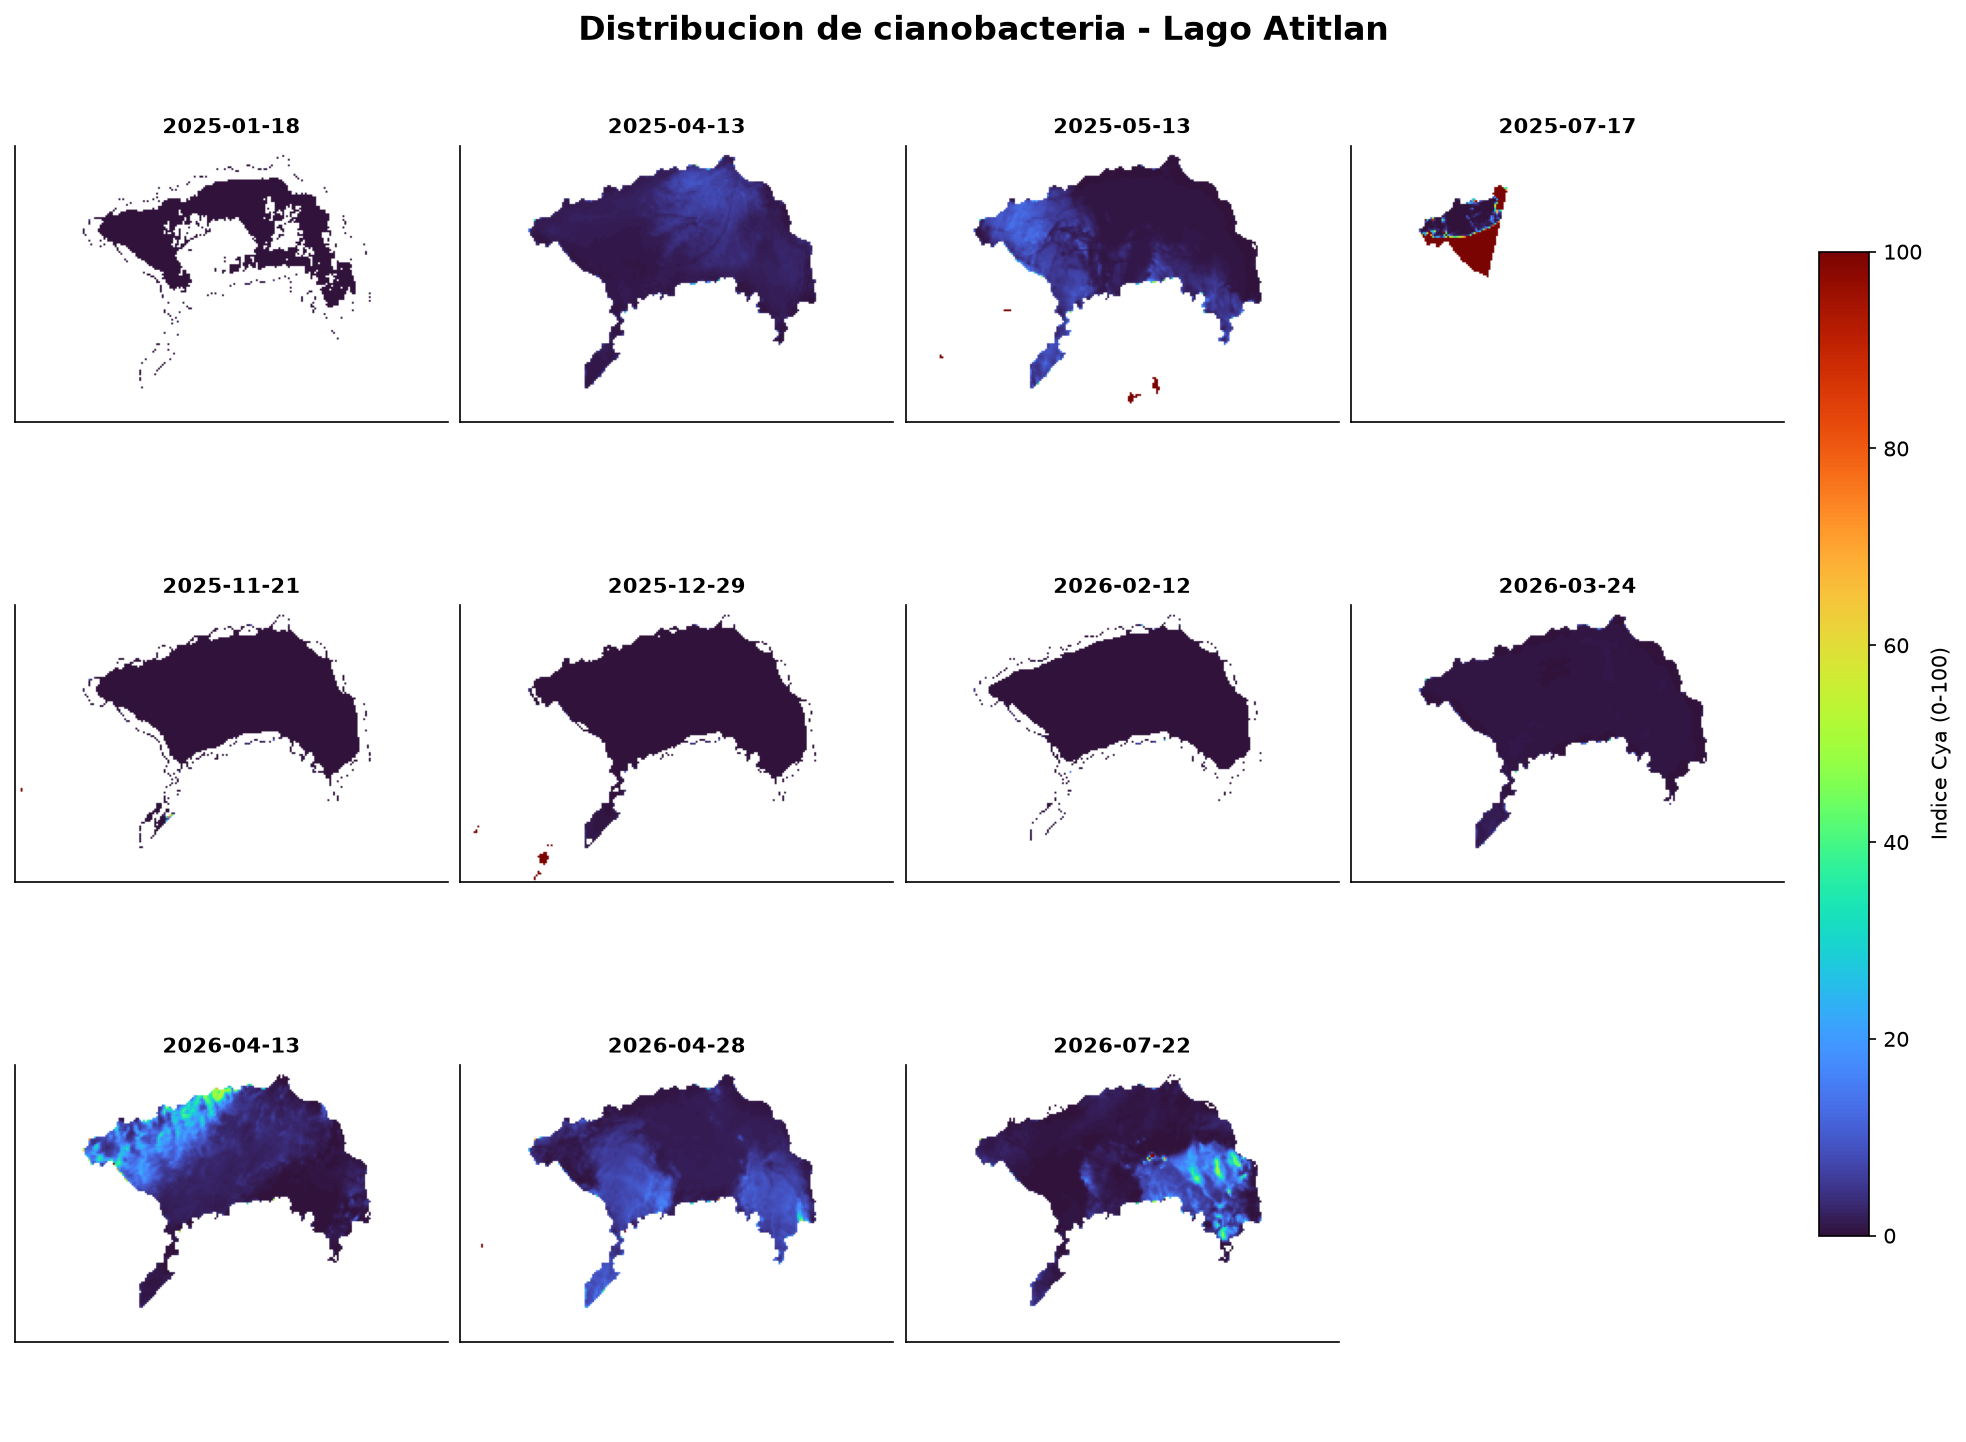

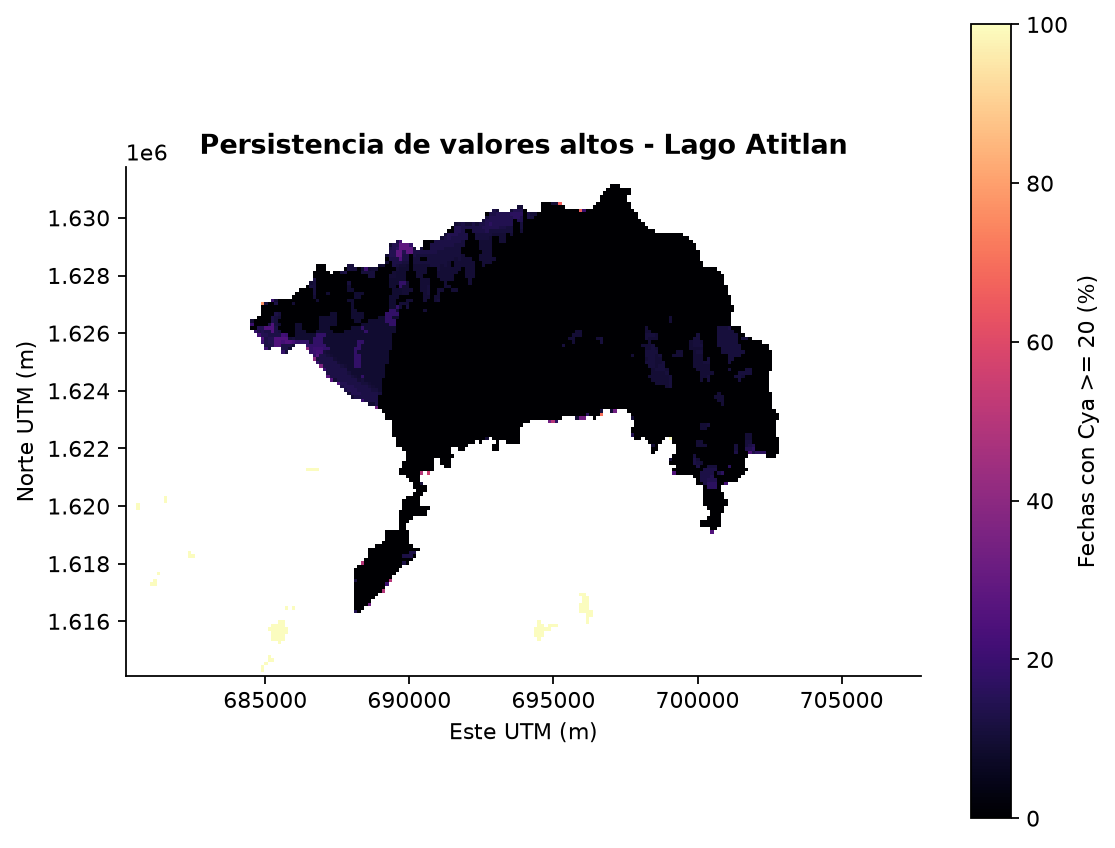

In [6]:
for lago in ("amatitlan", "atitlan"):
    display(Image(filename=str(CARPETA_FIGURAS / f"mapas_cianobacteria_{lago}.png"), width=950))
    display(Image(filename=str(CARPETA_FIGURAS / f"persistencia_{lago}.png"), width=600))

En Amatitlán la señal alta se repite en ambos cuerpos principales y no queda
reducida a un único punto. En Atitlán los valores altos son menos persistentes y
se concentran en observaciones concretas. Los pequeños fragmentos aislados fuera
del contorno principal provienen de la máscara espectral y no se interpretan
como parte del lago.

## 6. Correlación con NDVI y NDWI

Se usó una muestra reproducible de píxeles de todas las fechas. Spearman ayuda a
describir relaciones que no necesariamente forman una línea recta. La cantidad
de puntos vuelve detectables relaciones pequeñas, por eso importa más el tamaño
del coeficiente que el valor p.

,lago,indice,n,pearson_r,pearson_p,spearman_r,spearman_p
0,Amatitlan,NDVI,9090,0.4625,0.0,0.5362,0.0
1,Amatitlan,NDWI,9090,-0.3504,0.0,-0.4201,0.0
2,Atitlan,NDVI,31128,-0.0242,0.0,-0.3410,0.0
3,Atitlan,NDWI,31128,-0.4381,0.0,-0.9061,0.0


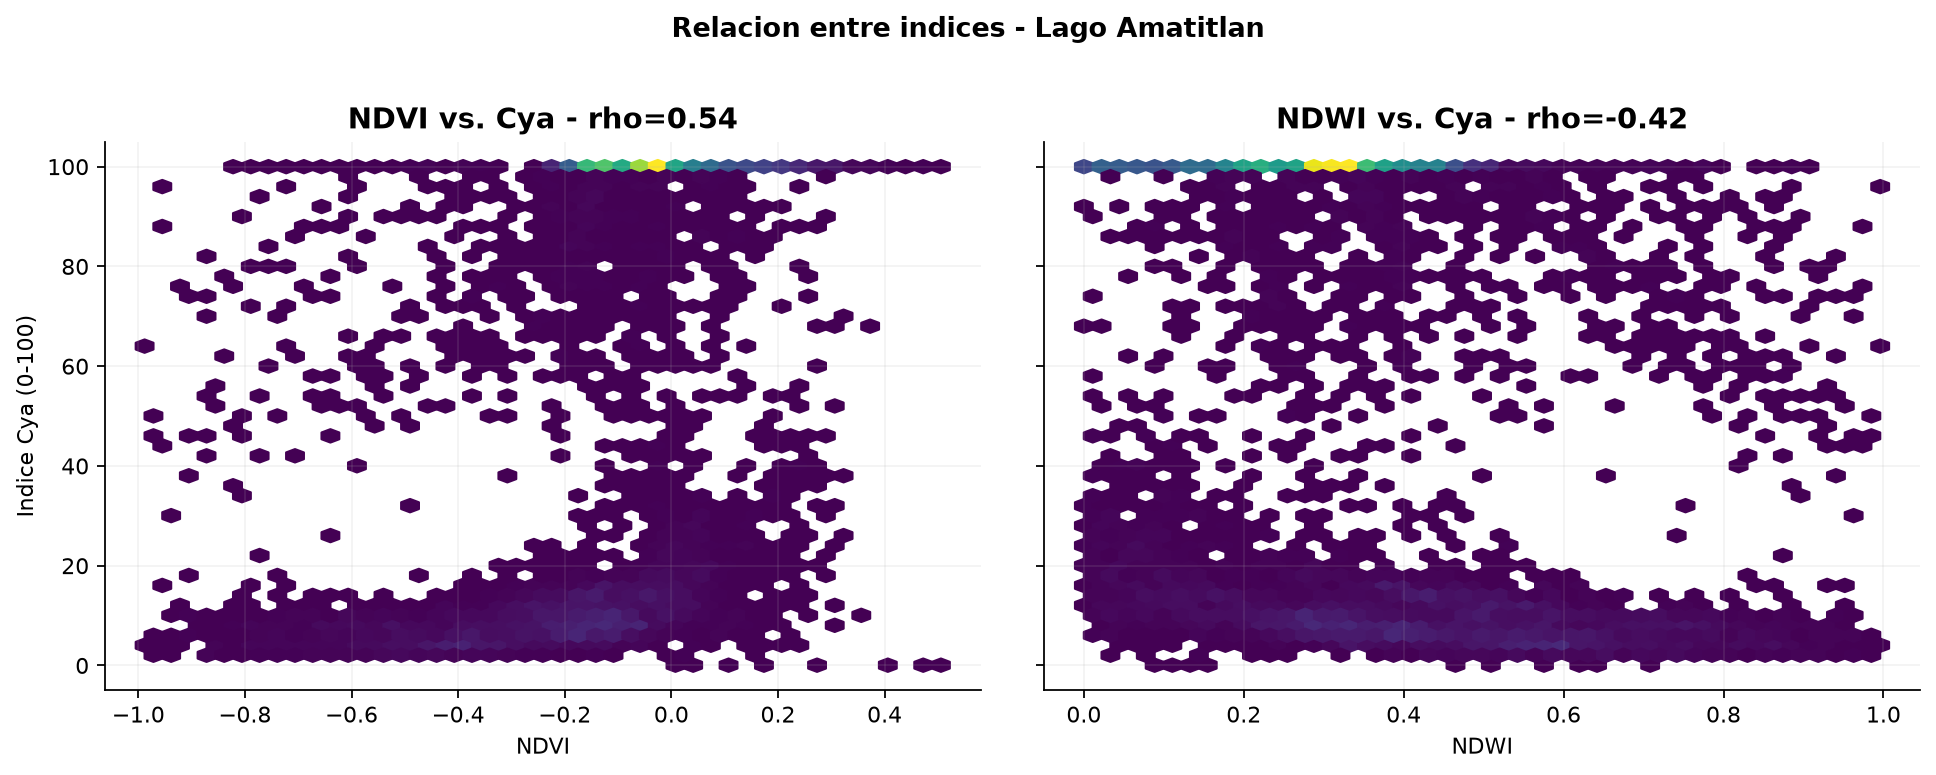

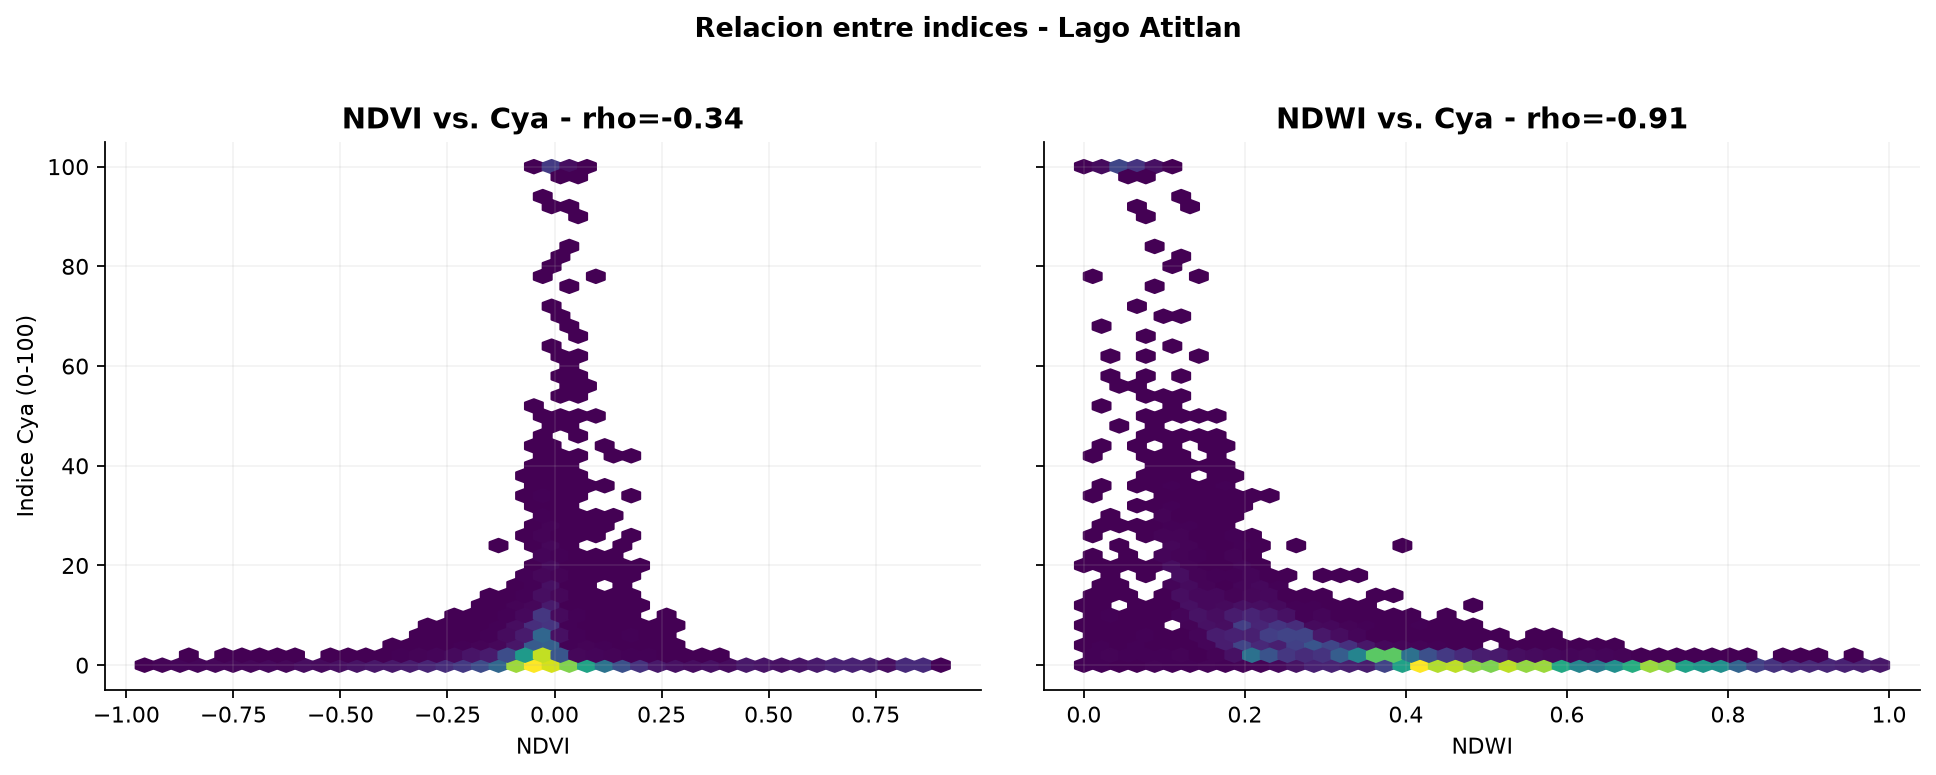

In [7]:
display(correlaciones.round(4))
for lago in ("amatitlan", "atitlan"):
    display(Image(filename=str(CARPETA_FIGURAS / f"correlaciones_{lago}.png"), width=850))

In [8]:
for lago in ("Amatitlan", "Atitlan"):
    fila = correlaciones[correlaciones["lago"] == lago].set_index("indice")
    print(
        f"{lago}: Cya tiene una relación de Spearman "
        f"{fila.loc['NDVI', 'spearman_r']:.2f} con NDVI y "
        f"{fila.loc['NDWI', 'spearman_r']:.2f} con NDWI."
    )

Amatitlan: Cya tiene una relación de Spearman 0.54 con NDVI y -0.42 con NDWI.
Atitlan: Cya tiene una relación de Spearman -0.34 con NDVI y -0.91 con NDWI.


## 7. Comparación entre los lagos

Amatitlán muestra mayor intensidad media y una proporción mucho mayor de agua
por encima del umbral. Atitlán tiene una señal generalmente baja, interrumpida
por un episodio fuerte en julio de 2025. La diferencia es compatible con la
mayor presión urbana y entrada de nutrientes alrededor de Amatitlán, pero las
imágenes por sí solas no demuestran la causa.

In [9]:
display(resumen.round(2))

,lago,promedio_periodo,mediana_periodo,fecha_maxima,valor_maximo,fechas_pico_iqr,area_alta_promedio_pct
0,Amatitlan,57.80,91.03,2026-04-13,98.90,0,59.19
1,Atitlan,6.49,2.56,2025-07-17,49.62,1,5.86


## 8. Análisis exploratorio adicional

Además del promedio se comparó la distribución completa, el cambio entre la
primera y la última fecha, la persistencia de zonas altas y una separación
descriptiva entre temporada seca y lluviosa.

,lago,temporada,observaciones,cya_promedio,area_alta_promedio_pct
0,Amatitlan,Lluviosa,1,91.03,99.88
1,Amatitlan,Seca,10,54.48,55.12
2,Atitlan,Lluviosa,3,19.08,18.69
3,Atitlan,Seca,8,1.77,1.05


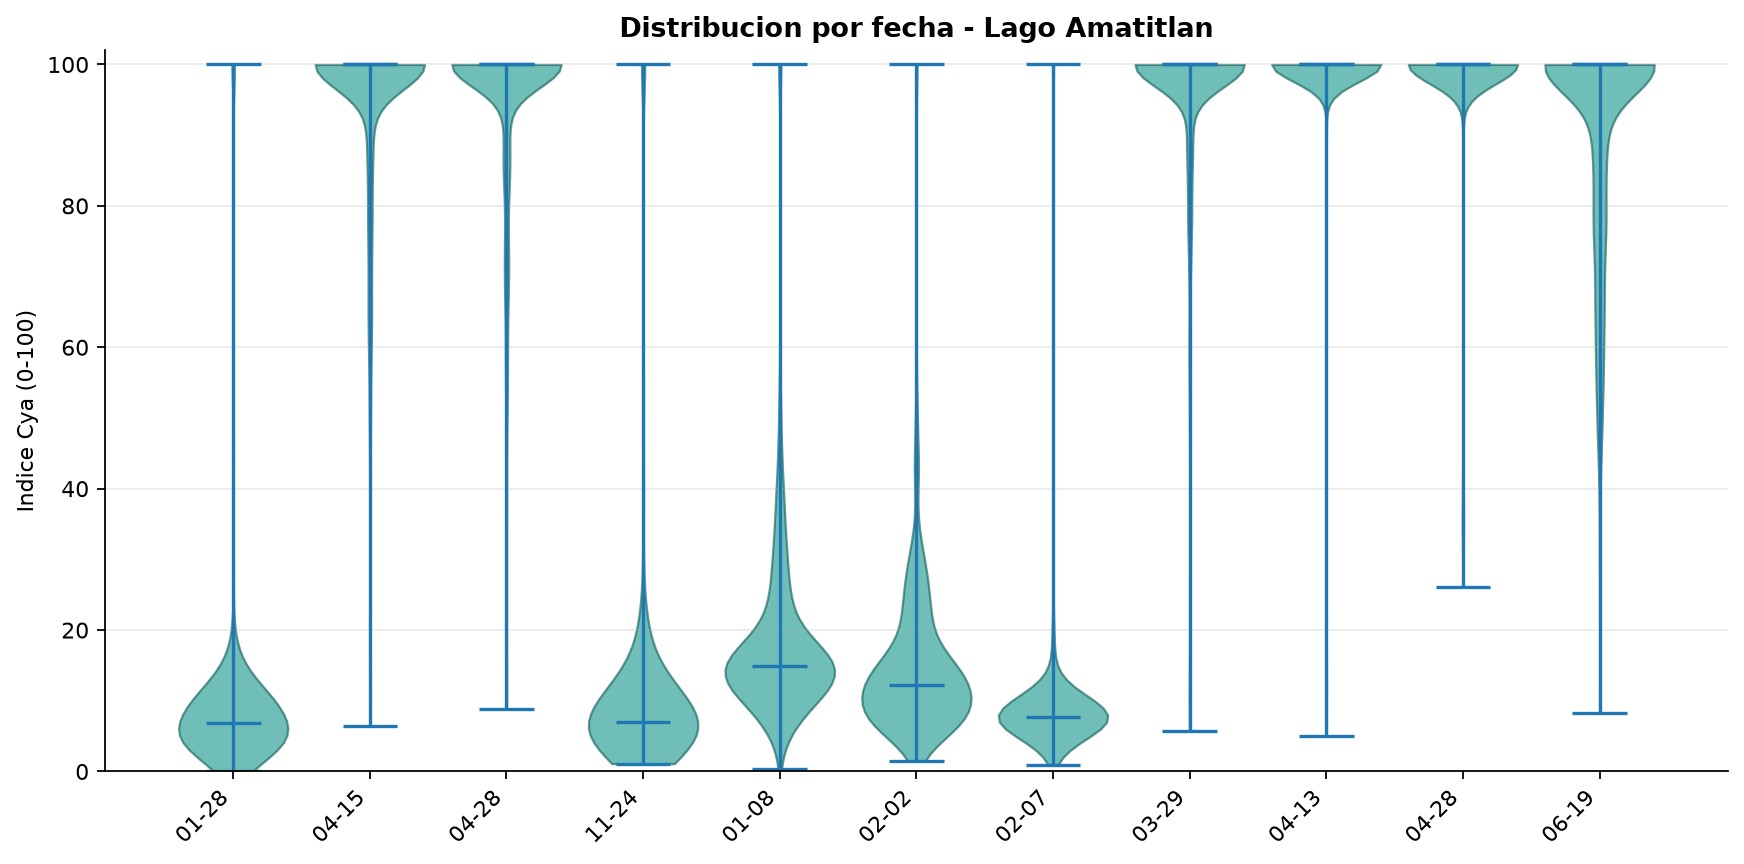

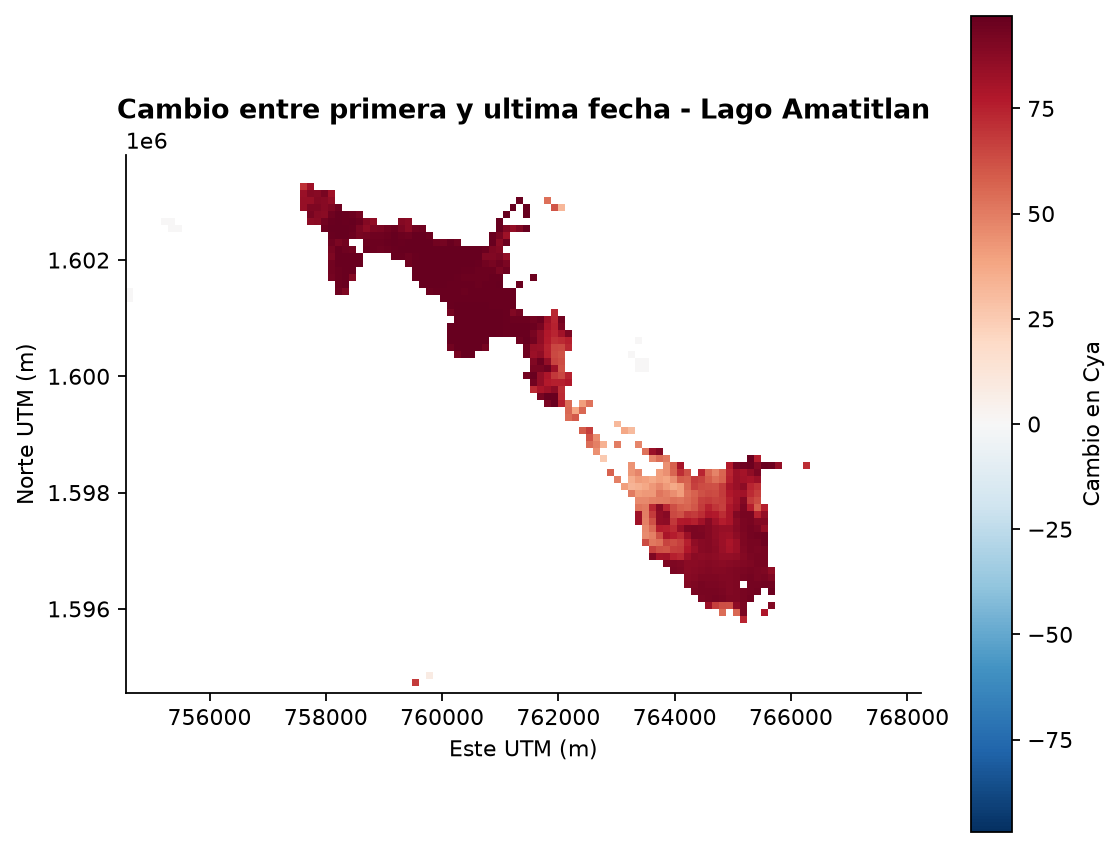

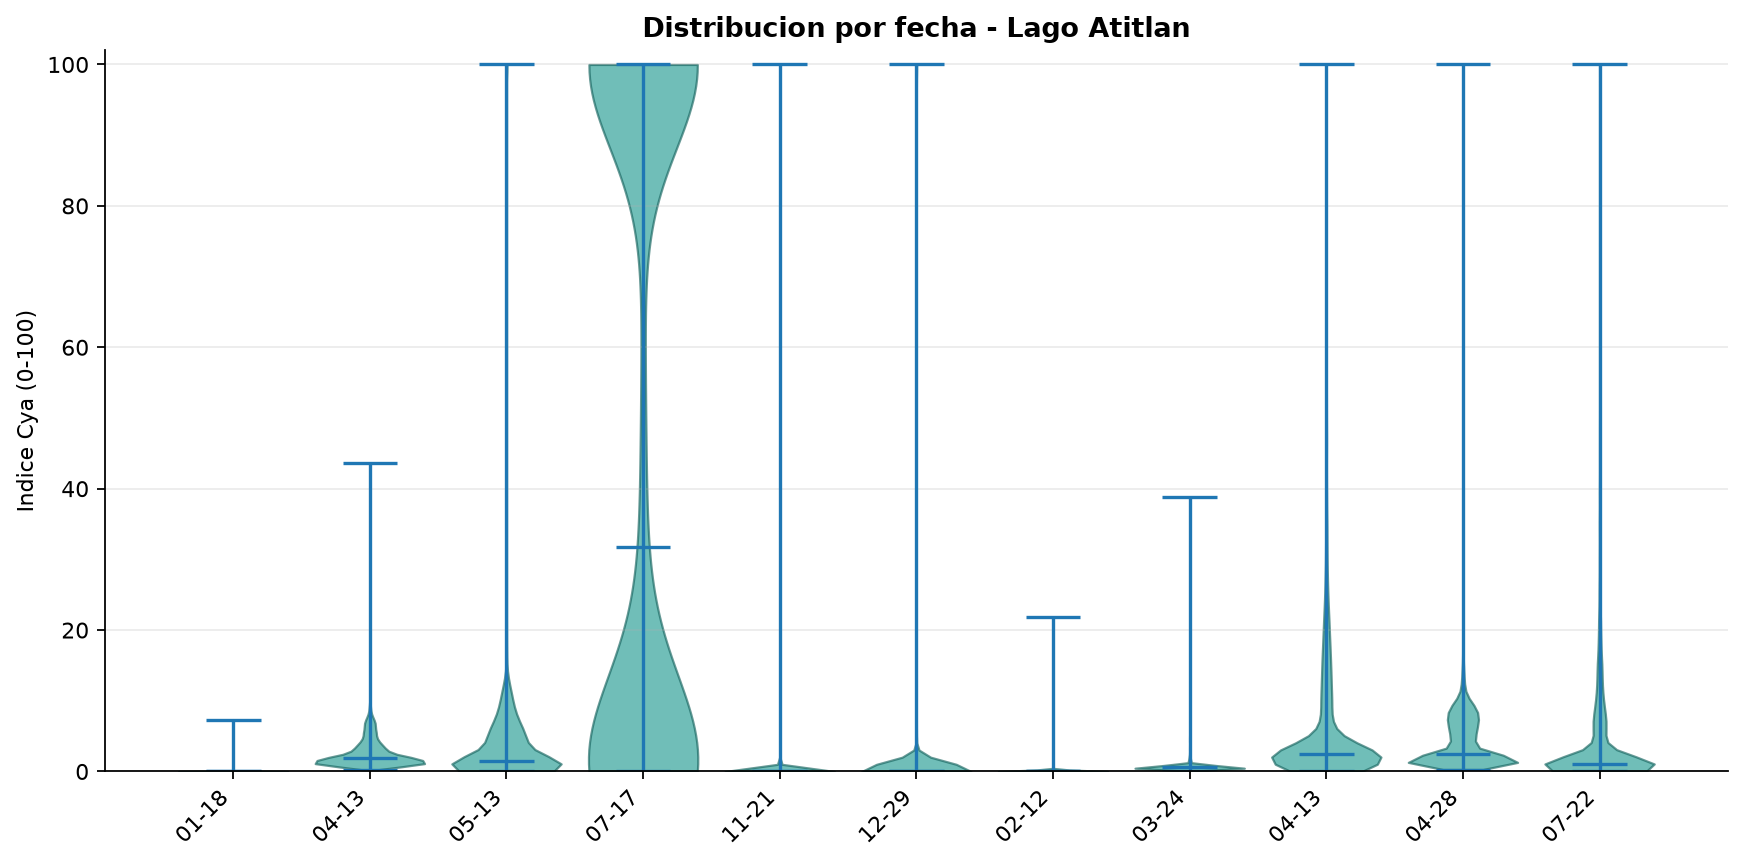

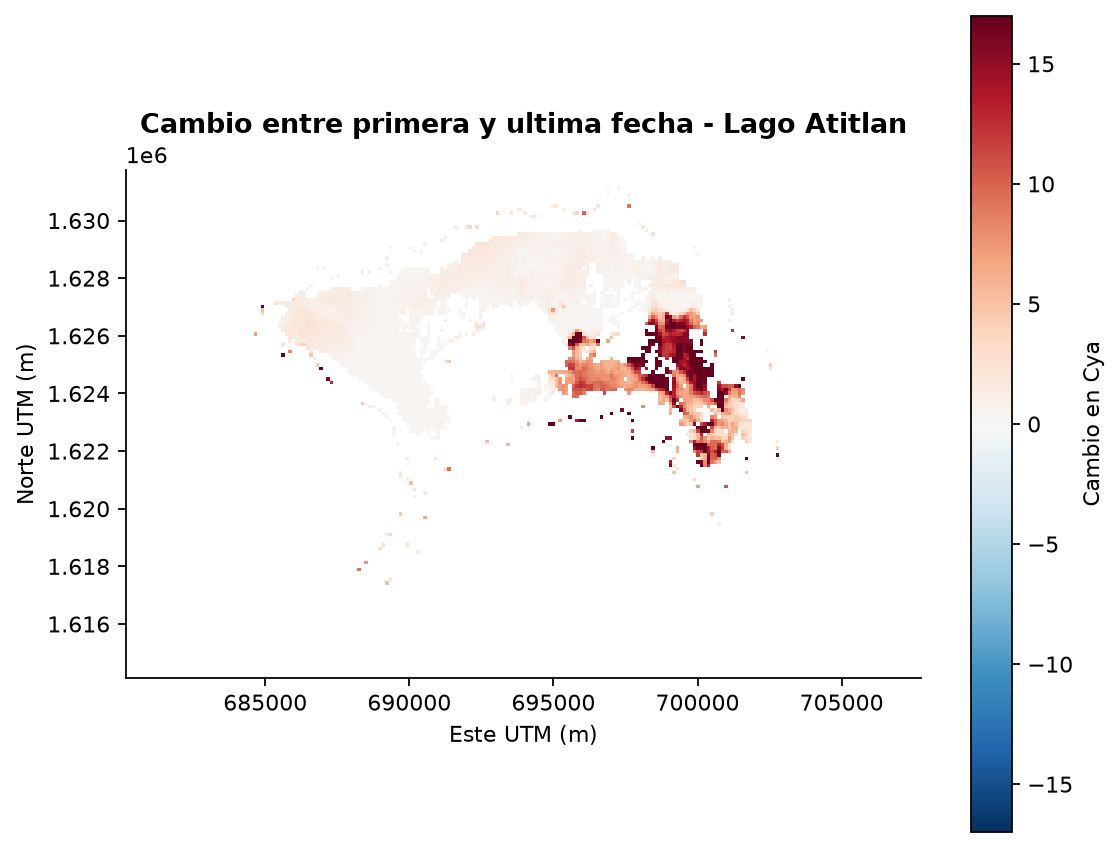

In [10]:
display(estacionalidad.round(2))
for lago in ("amatitlan", "atitlan"):
    display(Image(filename=str(CARPETA_FIGURAS / f"distribuciones_{lago}.png"), width=900))
    display(Image(filename=str(CARPETA_FIGURAS / f"diferencia_{lago}.png"), width=600))

La comparación por temporada debe leerse con prudencia: las fechas no están
espaciadas mensualmente y Amatitlán solo tiene una observación de época lluviosa.
Sí se observa que las distribuciones cambian con fuerza entre fechas y que
Amatitlán conserva una presencia alta en una fracción mucho mayor del lago.

## Conclusiones

1. Amatitlán presenta la señal más intensa, extensa y persistente del periodo.
2. Atitlán mantiene valores bajos en la mayoría de fechas, con un episodio
   crítico el 17 de julio de 2025 que debe revisarse junto con su cobertura válida.
3. Cya disminuye conforme aumenta NDWI en ambos lagos; la relación con NDVI
   cambia entre lagos y no debe interpretarse como causalidad.
4. Intensidad, extensión y persistencia describen aspectos distintos de una
   posible floración.
5. Los resultados sirven para orientar muestreos de campo, no para declarar que
   el agua es segura o tóxica.

## Reproducibilidad

El procesamiento completo está en `src/analisis_completo.py`; el flujo openEO
del avance se conserva en `src/procesamiento_geoespacial.py`. Las tablas y
figuras se regeneran desde las fechas oficiales sin guardar credenciales.

---

# Parte 2. Modelos de Machine Learning

**Avance: ejercicios 1, 2 y 3**

La Parte 1 dejó rasters de NDVI, NDWI y densidad estimada de cianobacteria (Cya)
para 11 fechas de Atitlán y 11 de Amatitlán. Aquí esos rasters se convierten en
una tabla donde cada fila es un píxel de agua con su posición, su fecha y sus
valores espectrales, para poder entrenar modelos que digan si una zona tiene
alta presencia de cianobacteria.

Las funciones viven en `src/ml_cianobacteria.py`. El módulo trae un
autochequeo (`python -m src.ml_cianobacteria`) que valida el umbral, la
ingeniería de características y el control de fuga sin necesitar rasters.

In [ ]:
from src.ml_cianobacteria import (
    construir_dataset, resumen_dataset, eda,
    agregar_respuesta, distribucion_respuesta, sensibilidad_umbral,
    ingenieria_caracteristicas, predictores, descripcion_predictores,
    revisar_fuga, UMBRAL_CYA, UMBRAL_OMS_CEL_ML,
)

# Requiere los GeoTIFF de la Parte 1 en data/processed/.
# Si aún no están descargados, esta celda avisa y las siguientes quedan vacías.
try:
    crudo = construir_dataset()
except FileNotFoundError as error:
    crudo = None
    print(error)

## 1. Preparación de los datos para Machine Learning

`construir_dataset()` recorre cada lago y cada fecha oficial, lee los rasters de
Cya, NDVI, NDWI y las bandas de reflectancia, y apila los píxeles en una sola
tabla. Las coordenadas salen del centro de cada píxel usando la transformación
afín del GeoTIFF, así que cada observación conserva su ubicación real.

### 1.3 Observaciones que se eliminan

| Descarte | Motivo |
|---|---|
| Píxeles con SCL de nube, sombra, cirro, nieve o saturación | Ya venían enmascarados desde openEO en la Parte 1; llegan como NoData |
| `cya` NaN o no finito | Sin valor de respuesta no hay observación |
| `cya` negativo | La densidad de células no puede ser negativa; indica división inestable |
| `ndwi < 0` | El píxel no es agua: está fuera del lago o sobre la orilla |

El filtro por NDWI es el que define "dentro del lago". Es el mismo criterio que
usó el script Se2WaQ en la Parte 1, así que la máscara del dataset y la de los
mapas coinciden.

In [ ]:
if crudo is not None:
    resumen = resumen_dataset(crudo)
    display(resumen["total"])
    display(resumen["por_lago"])
    display(resumen["por_fecha"])
    display(resumen["variables"])

### 1.5 Análisis exploratorio

In [ ]:
if crudo is not None:
    exploracion = eda(crudo)
    display(exploracion["descriptivas"])
    display(exploracion["correlaciones"])

### 1.6 Decisiones tomadas

- **Unidad de análisis: el píxel, no el lago.** Trabajar con el promedio por
  fecha dejaría 22 observaciones. A nivel de píxel hay miles, y el problema
  pasa a ser espacial, que es lo que pide la Parte 2.
- **Cya se guarda cruda y en log.** La densidad de células es muy asimétrica;
  `cya_log` sirve para graficar, pero el corte se aplica sobre la escala
  original para que el umbral tenga significado físico.
- **Las bandas se convierten a reflectancia** (factor 0.0001) antes de entrar a
  la tabla, igual que en la Parte 1.
- **No se imputan faltantes.** Un píxel sin dato es un píxel que el satélite no
  midió; inventar su valor metería ruido en un modelo espacial.
- **Se conserva `crs` y las coordenadas en grados.** La reproyección a
  EPSG:32615 se hace en el ejercicio 6, cuando se arman los bloques de 1 km.

## 2. Construcción de la variable respuesta

### 2.2 Criterio del punto de corte

El script Se2WaQ entrega la densidad estimada de cianobacteria en **10³ células
por mililitro**. El corte no se elige por conveniencia estadística sino por el
umbral sanitario:

> La OMS establece **100 000 células/mL** como el punto donde el riesgo para la
> salud en aguas recreativas deja de ser bajo y pasa a ser moderado
> (Alert Level 2). Por debajo, en **20 000 células/mL**, está el nivel de
> riesgo bajo o de vigilancia.

En las unidades del raster, 100 000 cel/mL son **100 unidades**. Ese es el valor
de `UMBRAL_CYA`, y coincide con el `UMBRAL_CYA_ALTO` que ya se usó para los
mapas de la Parte 1, de modo que el avance y la parte anterior hablan de lo
mismo cuando dicen "alta presencia".

**Referencias**

- WHO (2003). *Guidelines for safe recreational water environments. Volume 1:
  Coastal and fresh waters.* Ginebra: Organización Mundial de la Salud.
- WHO (2021). *Guidelines on recreational water quality. Volume 1: Coastal and
  fresh waters.* Ginebra: Organización Mundial de la Salud.
- Chorus, I. & Welch, M. (eds.) (2021). *Toxic Cyanobacteria in Water*, 2ª ed.
  CRC Press / WHO.
- Potes, M. et al. (2018). Se2WaQ – Sentinel-2 Water Quality script,
  Sentinel Hub Custom Scripts.

In [ ]:
if crudo is not None:
    datos = agregar_respuesta(crudo, umbral=UMBRAL_CYA)
    print(f"Umbral aplicado: {UMBRAL_CYA} x10^3 cel/mL = {UMBRAL_OMS_CEL_ML:,.0f} cel/mL")
    reparto = distribucion_respuesta(datos)
    display(reparto["global"])
    display(reparto["por_lago"])
    display(reparto["por_fecha"])

In [ ]:
if crudo is not None:
    display(sensibilidad_umbral(datos))

### 2.4 Desbalance

La tabla de sensibilidad muestra qué pasaría con otros cortes. Si la clase
positiva queda por debajo del 10 %, hay desbalance marcado y trae tres
consecuencias:

1. **Accuracy deja de servir.** Un modelo que prediga siempre "sin floración"
   acierta el 90 % y no detecta nada.
2. **El entrenamiento se sesga hacia la clase mayoritaria.** Se corrige con
   `class_weight="balanced"` en Regresión Logística y Random Forest, y con
   `scale_pos_weight` en XGBoost.
3. **La comparación entre modelos debe hacerse con Recall, F1 y ROC-AUC.**
   En contexto ambiental el error caro es el falso negativo: no avisar de una
   floración tóxica expone a bañistas y pescadores. Ese análisis se desarrolla
   completo en el ejercicio 5.

Si el corte de la OMS dejara una clase casi vacía en algún lago, se reportará
también el resultado con el percentil 90 observado, dejando claro que ese
segundo corte es relativo a los datos y no tiene interpretación sanitaria.

### 2.5 Variables que no pueden ser predictoras

La fórmula del índice es:

$$Cya = 115530.31 \cdot \left(\frac{B03 \cdot B04}{B02}\right)^{2.38}$$

Como la respuesta es `cya >= umbral`, quedan prohibidas `cya`, `cya_log` y las
tres bandas de la fórmula: **B02, B03 y B04**. Usarlas sería reconstruir la
respuesta con otro nombre.

Hay un segundo caso, menos evidente: **NDVI usa B04 y NDWI usa B03**. Ninguno es
la respuesta, pero ambos comparten insumo con ella. Por eso el módulo define dos
conjuntos: el **estricto**, sin NDVI ni NDWI, y el **amplio**, que los incluye.
Entrenar con ambos permite medir cuánto del desempeño viene de esa dependencia
en vez de asumirlo.

In [ ]:
if crudo is not None:
    datos = ingenieria_caracteristicas(datos)
    X_estricto = predictores(datos, estricto=True)
    X_amplio = predictores(datos, estricto=False)
    print("Estricto:", X_estricto)
    print("Amplio:  ", X_amplio)
    display(revisar_fuga(datos, X_estricto))

## 3. Selección y construcción de variables predictoras

### 3.2 y 3.3 Qué representa cada variable

La tabla siguiente reúne las predictoras, su tipo y por qué podrían ayudar a
identificar cianobacteria. Las variables temporales y espaciales son las
construidas en este avance (`ingenieria_caracteristicas`):

- **`mes` y `dia_del_anio`** — las floraciones son estacionales. `dia_del_anio`
  evita el corte artificial entre diciembre y enero que introduce `mes`.
- **`epoca_lluviosa`** — mayo a octubre en Guatemala. La escorrentía arrastra
  nutrientes agrícolas y aguas residuales hacia ambos lagos, que es justamente
  lo que alimenta una floración.
- **`es_amatitlan`** — los lagos difieren en profundidad, altitud y carga de
  nutrientes; sin esta variable el modelo trataría dos sistemas distintos como
  uno solo. Se retira en el ejercicio 7, donde entrenar en un lago y evaluar en
  el otro la volvería constante.
- **`dist_centro`** — distancia al centroide del lago. Aproxima la cercanía a la
  orilla y a las desembocaduras, donde se concentran los nutrientes y la
  floración se acumula por el viento.
- **`B08`** — infrarrojo cercano. Es la única banda del conjunto original que no
  entra en la fórmula de Cya, así que aporta información espectral limpia: el
  agua clara lo absorbe casi por completo, y un valor alto delata material
  particulado o biomasa flotante.

In [ ]:
if crudo is not None:
    display(descripcion_predictores(datos))

### Estado del avance

| Ejercicio | Estado |
|---|---|
| 1. Preparación del dataset | Pipeline listo; los conteos y el EDA salen al ejecutar con los rasters |
| 2. Variable respuesta | Umbral OMS justificado y aplicado; distribución y desbalance calculados |
| 3. Predictoras | Conjuntos estricto y amplio definidos, con control de fuga verificado |
| 4–8 | Entrega final |

**Pendiente para la entrega final:** descargar los rasters de la Parte 1 y las
bandas de reflectancia (`descargar_bandas`), y ejecutar el notebook completo
para llenar las tablas de este avance con los números reales.